In [2]:



import os, time, copy, random
from typing import Dict, Any, List, Tuple, Optional

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision import transforms
import timm

import torchquantum as tq
import torchquantum.functional as tqf

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc, precision_recall_fscore_support,
)
from sklearn.preprocessing import label_binarize



SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


TRAIN_DIR = "/home/jovyan/ssh-test-datavol-1/dataset/dataset/train"
VAL_DIR   = "/home/jovyan/ssh-test-datavol-1/dataset/dataset/val"






CKPT_ROOT    = "./checkpoints"
STAGE1_DIR   = os.path.join(CKPT_ROOT, "stage1")
STAGE2_DIR   = os.path.join(CKPT_ROOT, "stage2")
BASELINE_DIR = os.path.join(CKPT_ROOT, "baseline")
for d in (CKPT_ROOT, STAGE1_DIR, STAGE2_DIR, BASELINE_DIR):
    os.makedirs(d, exist_ok=True)


def _safe_name(s: str) -> str:
    """timm names like 'vit_base_patch16_224.dino' -> safe filename 'vit_base_patch16_224_dino'."""
    return s.replace("/", "__").replace(".", "_").replace(":", "_")


CFG: Dict[str, Any] = {

    "backbone":    "resnet18",
    "pretrained":  True,


    "n_qubits":    8,
    "n_qlayers":   1,
    "n_classes":   3,
    "class_names": ["no", "sphere", "vort"],


    "input_size":   150,
    "resize_to":    224,
    "imagenet_mean": [0.485, 0.456, 0.406],
    "imagenet_std":  [0.229, 0.224, 0.225],


    "batch_size":  256,
    "test_split":  0.10,


    "class_weights":    [1.0, 2.5, 2.0],
    "grad_clip":        1.0,
    "warmup_epochs":    5,
    "use_augmentation": True,


    "stage1_epochs":      40,
    "stage1_wd":          5e-4,
    "stage1_lr_backbone": 1e-4,
    "stage1_lr_bridge":   1e-3,
    "stage1_lr_quantum":  5e-3,


    "stage2_epochs": 60,
    "stage2_wd":     1e-4,
    "lr_backbone":   1e-4,
    "lr_bridge":     5e-4,
    "lr_quantum":    5e-3,

    "seed": SEED,
}



_bb = _safe_name(CFG["backbone"])
CFG["stage1_ckpt"]   = os.path.join(STAGE1_DIR,   f"{_bb}.pth")
CFG["stage2_ckpt"]   = os.path.join(STAGE2_DIR,   f"{_bb}.pth")
CFG["baseline_ckpt"] = os.path.join(BASELINE_DIR, f"{_bb}.pth")


print(f"PyTorch {torch.__version__} | TorchQuantum {tq.__version__} | timm {timm.__version__}")
print(f"Device: {device} | CUDA: {torch.cuda.is_available()}")
print(f"Backbone: {CFG['backbone']}  pretrained={CFG['pretrained']}")
print(f"Stage 1 LRs: backbone={CFG['stage1_lr_backbone']} "
      f"bridge={CFG['stage1_lr_bridge']} quantum={CFG['stage1_lr_quantum']}")
print(f"Stage 2 LRs: backbone={CFG['lr_backbone']} "
      f"bridge={CFG['lr_bridge']} quantum={CFG['lr_quantum']}")
print(f"class_weights={CFG['class_weights']}, grad_clip={CFG['grad_clip']}, "
      f"warmup={CFG['warmup_epochs']}, use_augmentation={CFG['use_augmentation']}")
print(f"\nCheckpoint layout:")
print(f"  stage1   -> {CFG['stage1_ckpt']}")
print(f"  stage2   -> {CFG['stage2_ckpt']}")
print(f"  baseline -> {CFG['baseline_ckpt']}")

PyTorch 2.5.1+cu124 | TorchQuantum 0.1.8 | timm 1.0.26
Device: cuda:0 | CUDA: True
Backbone: resnet18  pretrained=True
Stage 1 LRs: backbone=0.0001 bridge=0.001 quantum=0.005
Stage 2 LRs: backbone=0.0001 bridge=0.0005 quantum=0.005
class_weights=[1.0, 2.5, 2.0], grad_clip=1.0, warmup=5, use_augmentation=True

Checkpoint layout:
  stage1   -> ./checkpoints/stage1/resnet18.pth
  stage2   -> ./checkpoints/stage2/resnet18.pth
  baseline -> ./checkpoints/baseline/resnet18.pth


In [3]:


class GPUTensorDataset:
    def __init__(self, cache: torch.Tensor, labels: torch.Tensor, classes: List[str]):
        self.cache  = cache
        self.labels = labels
        self.classes = classes
    def __len__(self) -> int:
        return self.cache.size(0)


class GPULoader:
    def __init__(self, dataset: GPUTensorDataset, batch_size: int,
                 shuffle: bool = False, seed: int = 42):
        self.dataset = dataset
        self.bs = batch_size
        self.shuffle = shuffle
        self.seed = seed
        self._epoch = 0

    def __len__(self) -> int:
        return (len(self.dataset) + self.bs - 1) // self.bs

    def __iter__(self):
        n   = len(self.dataset)
        dev = self.dataset.cache.device
        if self.shuffle:
            g = torch.Generator(); g.manual_seed(self.seed + self._epoch)
            perm = torch.randperm(n, generator=g).to(dev)
        else:
            perm = torch.arange(n, device=dev)
        self._epoch += 1
        cache, labels = self.dataset.cache, self.dataset.labels
        for i in range(0, n, self.bs):
            idx = perm[i:i + self.bs]
            yield cache.index_select(0, idx).float(), labels.index_select(0, idx)


def build_gpu_cache(root_dir, resize_to, mean, std, device,
                    dtype: torch.dtype = torch.float32, chunk: int = 256):
    classes = sorted([d for d in os.listdir(root_dir)
                      if os.path.isdir(os.path.join(root_dir, d))])
    class_to_idx = {c: i for i, c in enumerate(classes)}
    files: List[Tuple[str, int]] = []
    for c in classes:
        cdir = os.path.join(root_dir, c)
        for f in os.listdir(cdir):
            if f.endswith(".npy"):
                files.append((os.path.join(cdir, f), class_to_idx[c]))

    N = len(files)
    cache  = torch.empty((N, 3, resize_to, resize_to), dtype=dtype,        device=device)
    labels = torch.empty((N,),                          dtype=torch.long, device=device)
    m = torch.tensor(mean, device=device, dtype=torch.float32).view(1, 3, 1, 1)
    s = torch.tensor(std,  device=device, dtype=torch.float32).view(1, 3, 1, 1)

    print(f"Caching {N} samples from {root_dir} -> GPU 3x{resize_to}x{resize_to} {dtype}")
    for cs in tqdm(range(0, N, chunk), desc="cache build"):
        ce = min(cs + chunk, N)
        cpu_imgs, cpu_lbls = [], []
        for fp, lbl in files[cs:ce]:
            arr = np.load(fp)
            if arr.ndim == 2:
                arr = arr[np.newaxis, :, :]
            elif arr.ndim == 3 and arr.shape[0] not in (1, 3):
                arr = arr.transpose(2, 0, 1)
            if arr.max() > 1.0:
                arr = arr / 255.0
            t = torch.from_numpy(np.ascontiguousarray(arr)).float()
            if t.shape[0] == 1:
                t = t.repeat(3, 1, 1)
            cpu_imgs.append(t)
            cpu_lbls.append(lbl)
        batch = torch.stack(cpu_imgs, dim=0).to(device, non_blocking=True)
        batch = F.interpolate(batch, size=(resize_to, resize_to),
                              mode="bilinear", align_corners=False)
        batch = (batch - m) / s
        cache[cs:ce]  = batch.to(dtype)
        labels[cs:ce] = torch.tensor(cpu_lbls, dtype=torch.long, device=device)
    return GPUTensorDataset(cache, labels, classes)


class GPUAugment(nn.Module):
    """
    Label-preserving augmentation, applied entirely on GPU on already-cached tensors.
    Per-sample h-flip, per-sample v-flip, per-batch 90-degree rotation.
    All three are exact rotation/flip symmetries of gravitational lensing labels,
    so they preserve {no, sphere, vort}.
    """
    def __init__(self, p_hflip: float = 0.5, p_vflip: float = 0.5, p_rot90: float = 0.75):
        super().__init__()
        self.p_hflip = p_hflip
        self.p_vflip = p_vflip
        self.p_rot90 = p_rot90

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B = x.shape[0]; dev = x.device
        m = (torch.rand(B, device=dev) < self.p_hflip).view(B, 1, 1, 1)
        x = torch.where(m, x.flip(-1), x)
        m = (torch.rand(B, device=dev) < self.p_vflip).view(B, 1, 1, 1)
        x = torch.where(m, x.flip(-2), x)
        if torch.rand(1, device=dev).item() < self.p_rot90:
            k = int(torch.randint(1, 4, (1,)).item())
            x = torch.rot90(x, k, dims=[-2, -1])
        return x


CACHE_DTYPE = torch.float32
t0 = time.time()
train_set = build_gpu_cache(TRAIN_DIR, CFG["resize_to"], CFG["imagenet_mean"], CFG["imagenet_std"],
                            device, dtype=CACHE_DTYPE)
val_full  = build_gpu_cache(VAL_DIR, CFG["resize_to"], CFG["imagenet_mean"], CFG["imagenet_std"],
                            device, dtype=CACHE_DTYPE)
print(f"Cache build took {time.time()-t0:.1f}s | "
      f"GPU mem allocated {torch.cuda.memory_allocated()/1e9:.2f} GB")

g = torch.Generator().manual_seed(CFG["seed"])
n_total = len(val_full); n_test = int(n_total * CFG["test_split"])
perm = torch.randperm(n_total, generator=g)
val_idx, test_idx = perm[n_test:].to(device), perm[:n_test].to(device)
val_set  = GPUTensorDataset(val_full.cache.index_select(0, val_idx),
                            val_full.labels.index_select(0, val_idx), val_full.classes)
test_set = GPUTensorDataset(val_full.cache.index_select(0, test_idx),
                            val_full.labels.index_select(0, test_idx), val_full.classes)
del val_full; torch.cuda.empty_cache()

LOADER_BS = CFG["batch_size"]
train_loader = GPULoader(train_set, batch_size=LOADER_BS, shuffle=True,  seed=CFG["seed"])
val_loader   = GPULoader(val_set,   batch_size=LOADER_BS, shuffle=False)
test_loader  = GPULoader(test_set,  batch_size=LOADER_BS, shuffle=False)

augmenter = GPUAugment().to(device) if CFG["use_augmentation"] else None
if augmenter is not None:
    print("GPUAugment ON: per-sample h/v flips + per-batch 90-deg rotation (label-preserving)")
else:
    print("GPUAugment OFF")

CLASS_NAMES = train_set.classes
assert CLASS_NAMES == CFG["class_names"], f"class mismatch: {CLASS_NAMES}"
print(f"Sizes: train={len(train_set)} val={len(val_set)} test={len(test_set)}")

import collections
counts = collections.Counter(train_set.labels.cpu().tolist())
print("Class counts (train):", {CLASS_NAMES[k]: v for k, v in sorted(counts.items())})

Caching 30000 samples from /home/jovyan/ssh-test-datavol-1/dataset/dataset/train -> GPU 3x224x224 torch.float32


cache build:   0%|          | 0/118 [00:00<?, ?it/s]

Caching 7500 samples from /home/jovyan/ssh-test-datavol-1/dataset/dataset/val -> GPU 3x224x224 torch.float32


cache build:   0%|          | 0/30 [00:00<?, ?it/s]

Cache build took 217.0s | GPU mem allocated 22.58 GB
GPUAugment ON: per-sample h/v flips + per-batch 90-deg rotation (label-preserving)
Sizes: train=30000 val=6750 test=750
Class counts (train): {'no': 10000, 'sphere': 10000, 'vort': 10000}


In [4]:


class VQC(tq.QuantumModule):
    def __init__(self, n_wires: int = 8, n_qlayers: int = 1):
        super().__init__()
        self.n_wires = n_wires
        self.n_qlayers = n_qlayers
        self.encoder = tq.GeneralEncoder([
            {"input_idx": [i], "func": "ry", "wires": [i]} for i in range(n_wires)
        ])
        self.params_rx_dct = tq.QuantumModuleDict()
        self.params_ry_dct = tq.QuantumModuleDict()
        self.params_rz_dct = tq.QuantumModuleDict()
        for k in range(n_qlayers):
            for i in range(n_wires):
                key = str(i + k * n_wires)
                self.params_rx_dct[key] = tq.RX(has_params=True, trainable=True)
                self.params_ry_dct[key] = tq.RY(has_params=True, trainable=True)
                self.params_rz_dct[key] = tq.RZ(has_params=True, trainable=True)
        self.measure = tq.MeasureAll(tq.PauliZ)

    @tq.static_support
    def forward(self, x: torch.Tensor, q_device: tq.QuantumDevice):
        self.q_device = q_device
        self.encoder(self.q_device, x)
        for k in range(self.n_qlayers):
            for i in range(self.n_wires):
                key = str(i + k * self.n_wires)
                self.params_rx_dct[key](self.q_device, wires=i)
                self.params_ry_dct[key](self.q_device, wires=i)
                self.params_rz_dct[key](self.q_device, wires=i)
            for i in range(self.n_wires):
                tgt = 0 if i == self.n_wires - 1 else i + 1
                tqf.cnot(self.q_device, wires=[i, tgt],
                         static=self.static_mode, parent_graph=self.graph)
        return self.measure(self.q_device)

In [5]:


def _make_bridge(in_dim: int, n_qubits: int, dropout: float = 0.2) -> nn.Sequential:
    dims = [in_dim, 256, 128, 64, 32, n_qubits]
    layers: List[nn.Module] = []
    for i in range(len(dims) - 2):
        d = dropout * (1.0 - 0.2 * i)
        layers += [
            nn.Linear(dims[i], dims[i + 1]),
            nn.BatchNorm1d(dims[i + 1]),
            nn.ReLU(inplace=True),
            nn.Dropout(d),
        ]
    layers.append(nn.Linear(dims[-2], dims[-1]))
    seq = nn.Sequential(*layers)

    for m in seq.modules():
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    return seq


class ResNet18FrontEnd(nn.Module):
    def __init__(self, n_qubits: int, pretrained: bool = True):
        super().__init__()
        weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = torchvision.models.resnet18(weights=weights)
        feat_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.bridge   = _make_bridge(in_dim=feat_dim, n_qubits=n_qubits, dropout=0.2)
        self.feat_dim = feat_dim
        self.n_qubits = n_qubits

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.bridge(self.backbone(x))


def get_frontend(name: str, n_qubits: int, pretrained: bool = True) -> nn.Module:
    name = name.lower()
    if name == "resnet18":
        return ResNet18FrontEnd(n_qubits=n_qubits, pretrained=pretrained)
    if name in {"resnet34", "resnet50", "efficientnet_b0",
                "convnext_tiny", "vit_b_16", "densenet121"}:
        raise NotImplementedError(f"Backbone '{name}' is a TODO.")
    raise ValueError(f"Unknown backbone: {name}")


_fe = get_frontend(CFG["backbone"], CFG["n_qubits"], CFG["pretrained"]).to(device)
_xb = torch.randn(2, 3, CFG["resize_to"], CFG["resize_to"], device=device)
_yb = _fe(_xb)
print(f"FrontEnd: {CFG['backbone']}  feat_dim={_fe.feat_dim} -> n_qubits={_fe.n_qubits}")
print(f"Output shape: {tuple(_yb.shape)}, "
      f"mean={_yb.mean():.3f}, std={_yb.std():.3f}")
print(f"Trainable params: {sum(p.numel() for p in _fe.parameters() if p.requires_grad):,}")
del _fe, _xb, _yb

FrontEnd: resnet18  feat_dim=512 -> n_qubits=8
Output shape: (2, 8), mean=0.173, std=1.181
Trainable params: 11,352,296


In [6]:



class Stage1Model(nn.Module):
    """
    Strictly mirrors vqc_classifier.py:TTN_VQC architecture and forward logic.
    The ONLY difference from Stage2Model is what gets loaded later: Stage 1
    starts everything from scratch (ImageNet backbone + random VQC + random head),
    Stage 2 will reload only the frontend.* keys from the Stage 1 checkpoint.
    """
    def __init__(self, frontend: nn.Module, n_qubits: int, n_qlayers: int, n_classes: int):
        super().__init__()
        self.frontend = frontend
        self.n_qubits = n_qubits
        self.vqc  = VQC(n_wires=n_qubits, n_qlayers=n_qlayers)
        self.head = nn.Linear(n_qubits, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        bsz = x.shape[0]
        qdev = tq.QuantumDevice(n_wires=self.n_qubits, bsz=bsz, device=x.device)
        pre_out = self.frontend(x)
        q_in = torch.sigmoid(pre_out) * (np.pi / 2.0)
        q_out = self.vqc(q_in, qdev)
        return F.log_softmax(self.head(q_out), dim=1)


def build_stage1_model(cfg: Dict[str, Any]) -> Stage1Model:
    fe = get_frontend(cfg["backbone"], cfg["n_qubits"], pretrained=cfg["pretrained"])
    return Stage1Model(fe, n_qubits=cfg["n_qubits"],
                       n_qlayers=cfg["n_qlayers"],
                       n_classes=cfg["n_classes"])


_m1 = build_stage1_model(CFG).to(device)
_xb = torch.randn(2, 3, CFG["resize_to"], CFG["resize_to"], device=device)
_yb = _m1(_xb)
print(f"Stage1Model (paper-faithful) out shape: {tuple(_yb.shape)}")
print(f"Stage1Model params: {sum(p.numel() for p in _m1.parameters()):,}")
print("  frontend.backbone:", sum(p.numel() for p in _m1.frontend.backbone.parameters()))
print("  frontend.bridge:  ", sum(p.numel() for p in _m1.frontend.bridge.parameters()))
print("  vqc:              ", sum(p.numel() for p in _m1.vqc.parameters()))
print("  head:             ", sum(p.numel() for p in _m1.head.parameters()))
del _m1, _xb, _yb

Stage1Model (paper-faithful) out shape: (2, 3)
Stage1Model params: 11,352,347
  frontend.backbone: 11176512
  frontend.bridge:   175784
  vqc:               24
  head:              27


In [7]:


def get_stage1_param_groups(model: Stage1Model, cfg: Dict[str, Any]) -> List[Dict[str, Any]]:
    return [
        {"params": list(model.frontend.backbone.parameters()),
         "lr": cfg["stage1_lr_backbone"], "name": "backbone"},
        {"params": list(model.frontend.bridge.parameters()),
         "lr": cfg["stage1_lr_bridge"],   "name": "bridge"},
        {"params": list(model.vqc.parameters()) + list(model.head.parameters()),
         "lr": cfg["stage1_lr_quantum"],  "name": "quantum"},
    ]


def warmup_cosine_factor(epoch: int, warmup: int, total: int) -> float:
    if warmup > 0 and epoch < warmup:
        return (epoch + 1) / warmup
    progress = (epoch - warmup) / max(1, total - warmup)
    return 0.5 * (1.0 + np.cos(np.pi * progress))


def run_stage1(cfg, train_loader, val_loader, augmenter: Optional[nn.Module] = None):
    torch.manual_seed(cfg["seed"])
    model = build_stage1_model(cfg).to(device)

    cw = cfg.get("class_weights")
    if cw is not None and any(w != 1.0 for w in cw):
        cw_t = torch.tensor(cw, dtype=torch.float32, device=device)
        criterion = nn.NLLLoss(weight=cw_t)
        print(f"[S1] using class weights {cw}")
    else:
        criterion = nn.NLLLoss()

    optimizer = optim.Adam(get_stage1_param_groups(model, cfg), weight_decay=cfg["stage1_wd"])
    scheduler = LambdaLR(
        optimizer,
        lr_lambda=lambda e: warmup_cosine_factor(e, cfg["warmup_epochs"], cfg["stage1_epochs"]),
    )

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_state = -1.0, None

    print(f"[S1] paper-faithful: frontend + VQC + Linear({cfg['n_qubits']}->{cfg['n_classes']})")
    print(f"[S1] augmentation: {'ON' if augmenter is not None else 'OFF'}")
    print(f"[S1] Trainable params: "
          f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    for epoch in range(cfg["stage1_epochs"]):
        model.train()
        tr_loss = tr_correct = tr_total = 0
        pbar = tqdm(train_loader, desc=f"[S1] ep {epoch+1}/{cfg['stage1_epochs']}", leave=False)
        for xb, yb in pbar:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            if augmenter is not None and model.training:
                xb = augmenter(xb)
            optimizer.zero_grad(set_to_none=True)
            logp = model(xb)
            loss = criterion(logp, yb)
            loss.backward()
            if cfg.get("grad_clip"):
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            optimizer.step()
            tr_loss    += loss.item() * xb.size(0)
            tr_correct += (logp.argmax(1) == yb).sum().item()
            tr_total   += xb.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        train_loss, train_acc = tr_loss / tr_total, tr_correct / tr_total

        model.eval()
        v_loss = v_correct = v_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                logp = model(xb)
                v_loss    += criterion(logp, yb).item() * xb.size(0)
                v_correct += (logp.argmax(1) == yb).sum().item()
                v_total   += xb.size(0)
        val_loss, val_acc = v_loss / v_total, v_correct / v_total

        for k, v in zip(["train_loss", "train_acc", "val_loss", "val_acc"],
                        [train_loss, train_acc, val_loss, val_acc]):
            history[k].append(v)

        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, cfg["stage1_ckpt"])

        scheduler.step()
        lrs = " ".join(f"{g['name']}={g['lr']:.1e}" for g in optimizer.param_groups)
        print(f"[S1] ep {epoch+1:02d}/{cfg['stage1_epochs']} | {lrs} | "
              f"train loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val loss={val_loss:.4f} acc={val_acc:.4f} {'*' if is_best else ''}")

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"\n[S1] Best val acc: {best_val_acc:.4f}")
    print(f"[S1] Saved best ckpt: {cfg['stage1_ckpt']}")
    return model, history


t0 = time.time()
stage1_model, stage1_history = run_stage1(CFG, train_loader, val_loader, augmenter=augmenter)
print(f"[S1] total time: {(time.time()-t0)/60:.1f} min")

[S1] using class weights [1.0, 2.5, 2.0]
[S1] paper-faithful: frontend + VQC + Linear(8->3)
[S1] augmentation: ON
[S1] Trainable params: 11,352,347


[S1] ep 1/40:   0%|          | 0/118 [00:00<?, ?it/s]

[S1] ep 01/40 | backbone=4.0e-05 bridge=4.0e-04 quantum=2.0e-03 | train loss=1.0874 acc=0.3343 | val loss=1.0734 acc=0.3356 *


[S1] ep 2/40:   0%|          | 0/118 [00:00<?, ?it/s]

[S1] ep 02/40 | backbone=6.0e-05 bridge=6.0e-04 quantum=3.0e-03 | train loss=1.0479 acc=0.3361 | val loss=1.0188 acc=0.3335 


...

[S1] ep 38/40 | backbone=8.0e-07 bridge=8.0e-06 quantum=4.0e-05 | train loss=0.0917 acc=0.9742 | val loss=0.1598 acc=0.9559 *


[S1] ep 39/40:   0%|          | 0/118 [00:00<?, ?it/s]

[S1] ep 39/40 | backbone=2.0e-07 bridge=2.0e-06 quantum=1.0e-05 | train loss=0.0912 acc=0.9741 | val loss=0.1666 acc=0.9507 


[S1] ep 40/40:   0%|          | 0/118 [00:00<?, ?it/s]

[S1] ep 40/40 | backbone=0.0e+00 bridge=0.0e+00 quantum=0.0e+00 | train loss=0.0922 acc=0.9727 | val loss=0.1740 acc=0.9476 

[S1] Best val acc: 0.9559
[S1] Saved best ckpt: ./checkpoints/stage1/resnet18.pth
[S1] total time: 5.4 min


eval:   0%|          | 0/3 [00:00<?, ?it/s]


=== Stage 1 (classical, ResNet-18) ===
Test accuracy: 0.9653
Macro ROC-AUC: 0.9927
              precision    recall  f1-score   support

          no     0.9456    0.9869    0.9658       229
      sphere     0.9592    0.9438    0.9514       249
        vort     0.9887    0.9669    0.9777       272

    accuracy                         0.9653       750
   macro avg     0.9645    0.9659    0.9650       750
weighted avg     0.9658    0.9653    0.9653       750



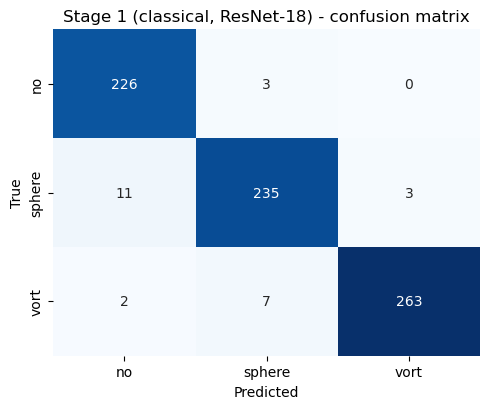

In [8]:


@torch.no_grad()
def collect_predictions(model: nn.Module, loader, dev):
    model.eval()
    all_logp, all_y = [], []
    for xb, yb in tqdm(loader, desc="eval", leave=False):
        xb = xb.to(dev, non_blocking=True)
        all_logp.append(model(xb).cpu())
        all_y.append(yb.detach().cpu())
    logp  = torch.cat(all_logp, dim=0).numpy()
    y     = torch.cat(all_y,    dim=0).numpy()
    probs = np.exp(logp)
    return probs, probs.argmax(axis=1), y


def plot_confusion(cm, class_names, title):
    fig, ax = plt.subplots(figsize=(5.0, 4.2))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    plt.tight_layout(); plt.show()


def evaluate_classifier(model, loader, class_names, tag: str):
    probs, preds, y = collect_predictions(model, loader, device)
    acc = accuracy_score(y, preds)
    y_bin = label_binarize(y, classes=list(range(len(class_names))))
    macro_auc = roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")
    cm = confusion_matrix(y, preds)
    print(f"\n=== {tag} ===")
    print(f"Test accuracy: {acc:.4f}")
    print(f"Macro ROC-AUC: {macro_auc:.4f}")
    print(classification_report(y, preds, target_names=class_names, digits=4))
    plot_confusion(cm, class_names, title=f"{tag} - confusion matrix")
    return {"tag": tag, "accuracy": acc, "macro_auc": macro_auc,
            "probs": probs, "preds": preds, "targets": y}


stage1_results = evaluate_classifier(
    stage1_model, test_loader, CLASS_NAMES,
    tag="Stage 1 (classical, ResNet-18)")

In [9]:


class Stage2Model(nn.Module):
    def __init__(self, frontend: nn.Module, n_qubits: int, n_qlayers: int, n_classes: int):
        super().__init__()
        self.frontend = frontend
        self.n_qubits = n_qubits
        self.vqc  = VQC(n_wires=n_qubits, n_qlayers=n_qlayers)
        self.head = nn.Linear(n_qubits, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        bsz = x.shape[0]
        qdev = tq.QuantumDevice(n_wires=self.n_qubits, bsz=bsz, device=x.device)
        pre_out = self.frontend(x)
        q_in = torch.sigmoid(pre_out) * (np.pi / 2.0)
        q_out = self.vqc(q_in, qdev)
        return F.log_softmax(self.head(q_out), dim=1)


def build_stage2_model(cfg) -> Stage2Model:
    fe = get_frontend(cfg["backbone"], cfg["n_qubits"], pretrained=cfg["pretrained"])
    return Stage2Model(fe, n_qubits=cfg["n_qubits"],
                       n_qlayers=cfg["n_qlayers"], n_classes=cfg["n_classes"])

In [10]:

def load_frontend_from_stage1(stage2_model, stage1_ckpt_path, strict=True):
    saved = torch.load(stage1_ckpt_path, map_location="cpu")
    fe_state = stage2_model.frontend.state_dict()
    fe_from_saved = {k[len("frontend."):]: v for k, v in saved.items()
                     if k.startswith("frontend.")}
    n_loaded = 0
    for k in fe_state.keys():
        if k in fe_from_saved and fe_from_saved[k].shape == fe_state[k].shape:
            fe_state[k] = fe_from_saved[k]
            n_loaded += 1
    result = stage2_model.frontend.load_state_dict(fe_state, strict=strict)
    print(f"[FE-load] loaded {n_loaded}/{len(fe_state)} frontend keys")
    if getattr(result, "missing_keys", []):    print(f"  missing:    {result.missing_keys}")
    if getattr(result, "unexpected_keys", []): print(f"  unexpected: {result.unexpected_keys}")
    return stage2_model

In [11]:

def get_stage2_param_groups(model: 'Stage2Model', cfg: Dict[str, Any]) -> List[Dict[str, Any]]:
    return [
        {"params": list(model.frontend.backbone.parameters()),
         "lr": cfg["lr_backbone"], "name": "backbone"},
        {"params": list(model.frontend.bridge.parameters()),
         "lr": cfg["lr_bridge"],   "name": "bridge"},
        {"params": list(model.vqc.parameters()) + list(model.head.parameters()),
         "lr": cfg["lr_quantum"],  "name": "quantum"},
    ]


def run_stage2(cfg, train_loader, val_loader, load_stage1: bool,
               ckpt_save_path: str, run_tag: str,
               augmenter: Optional[nn.Module] = None):
    torch.manual_seed(cfg["seed"])
    model = build_stage2_model(cfg).to(device)
    if load_stage1:

        model = load_frontend_from_stage1(model, cfg["stage1_ckpt"], strict=True)
    else:
        print(f"[{run_tag}] Skipping Stage-1 weights -> ImageNet-only.")

    cw = cfg.get("class_weights")
    if cw is not None and any(w != 1.0 for w in cw):
        cw_t = torch.tensor(cw, dtype=torch.float32, device=device)
        criterion = nn.NLLLoss(weight=cw_t)
    else:
        criterion = nn.NLLLoss()

    optimizer = optim.Adam(get_stage2_param_groups(model, cfg), weight_decay=cfg["stage2_wd"])
    scheduler = LambdaLR(
        optimizer,
        lr_lambda=lambda e: warmup_cosine_factor(e, cfg["warmup_epochs"], cfg["stage2_epochs"]),
    )

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_state = -1.0, None
    print(f"[{run_tag}] augmentation: {'ON' if augmenter is not None else 'OFF'}")

    for epoch in range(cfg["stage2_epochs"]):
        model.train()
        tr_loss = tr_correct = tr_total = 0
        pbar = tqdm(train_loader, desc=f"[{run_tag}] ep {epoch+1}/{cfg['stage2_epochs']}", leave=False)
        for xb, yb in pbar:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            if augmenter is not None and model.training:
                xb = augmenter(xb)
            optimizer.zero_grad(set_to_none=True)
            logp = model(xb)
            loss = criterion(logp, yb)
            loss.backward()
            if cfg.get("grad_clip"):
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            optimizer.step()
            tr_loss    += loss.item() * xb.size(0)
            tr_correct += (logp.argmax(1) == yb).sum().item()
            tr_total   += xb.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        train_loss, train_acc = tr_loss / tr_total, tr_correct / tr_total

        model.eval()
        v_loss = v_correct = v_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                logp = model(xb)
                v_loss    += criterion(logp, yb).item() * xb.size(0)
                v_correct += (logp.argmax(1) == yb).sum().item()
                v_total   += xb.size(0)
        val_loss, val_acc = v_loss / v_total, v_correct / v_total

        for k, v in zip(["train_loss", "train_acc", "val_loss", "val_acc"],
                        [train_loss, train_acc, val_loss, val_acc]):
            history[k].append(v)

        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, ckpt_save_path)

        scheduler.step()
        lrs = " ".join(f"{g['name']}={g['lr']:.1e}" for g in optimizer.param_groups)
        print(f"[{run_tag}] ep {epoch+1:02d}/{cfg['stage2_epochs']} | {lrs} | "
              f"train loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val loss={val_loss:.4f} acc={val_acc:.4f} {'*' if is_best else ''}")

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"\n[{run_tag}] Best val acc: {best_val_acc:.4f}")
    print(f"[{run_tag}] Saved best ckpt: {ckpt_save_path}")
    return model, history


t0 = time.time()
pre_vqc_model, pre_vqc_history = run_stage2(
    CFG, train_loader, val_loader,
    load_stage1=True,
    ckpt_save_path=CFG["stage2_ckpt"],
    run_tag="Pre+ResNet18-VQC",
    augmenter=augmenter,
)
print(f"[Pre+ResNet18-VQC] total time: {(time.time()-t0)/60:.1f} min")

[FE-load] loaded 150/150 frontend keys
[Pre+ResNet18-VQC] augmentation: ON


/tmp/ipykernel_167/2612156915.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  saved = torch.load(stage1_ckpt_path, map_location="cpu")


[Pre+ResNet18-VQC] ep 1/60:   0%|          | 0/118 [00:00<?, ?it/s]

[Pre+ResNet18-VQC] ep 01/60 | backbone=4.0e-05 bridge=2.0e-04 quantum=2.0e-03 | train loss=1.0457 acc=0.4514 | val loss=0.9595 acc=0.6274 *


[Pre+ResNet18-VQC] ep 2/60:   0%|          | 0/118 [00:00<?, ?it/s]

...

[Pre+ResNet18-VQC] ep 58/60 | backbone=3.3e-07 bridge=1.6e-06 quantum=1.6e-05 | train loss=0.0273 acc=0.9931 | val loss=0.1977 acc=0.9582 


[Pre+ResNet18-VQC] ep 59/60:   0%|          | 0/118 [00:00<?, ?it/s]

[Pre+ResNet18-VQC] ep 59/60 | backbone=8.2e-08 bridge=4.1e-07 quantum=4.1e-06 | train loss=0.0277 acc=0.9930 | val loss=0.1839 acc=0.9612 


[Pre+ResNet18-VQC] ep 60/60:   0%|          | 0/118 [00:00<?, ?it/s]

[Pre+ResNet18-VQC] ep 60/60 | backbone=0.0e+00 bridge=0.0e+00 quantum=0.0e+00 | train loss=0.0239 acc=0.9942 | val loss=0.1804 acc=0.9625 *

[Pre+ResNet18-VQC] Best val acc: 0.9625
[Pre+ResNet18-VQC] Saved best ckpt: ./checkpoints/stage2/resnet18.pth
[Pre+ResNet18-VQC] total time: 8.1 min


eval:   0%|          | 0/3 [00:00<?, ?it/s]


=== Pre+ResNet18-VQC ===
Test accuracy: 0.9680
Macro ROC-AUC: 0.9956
Macro P/R/F1: 0.9672 / 0.9682 / 0.9676
              precision    recall  f1-score   support

          no     0.9494    0.9825    0.9657       229
      sphere     0.9672    0.9478    0.9574       249
        vort     0.9851    0.9743    0.9797       272

    accuracy                         0.9680       750
   macro avg     0.9672    0.9682    0.9676       750
weighted avg     0.9683    0.9680    0.9680       750



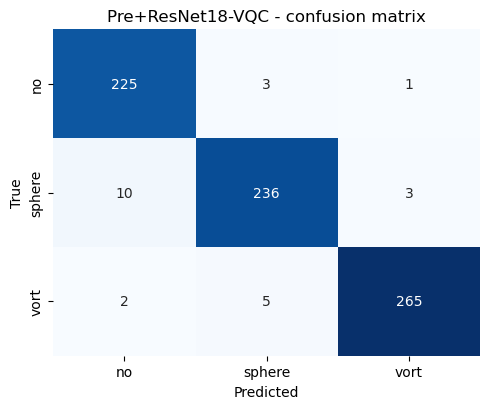

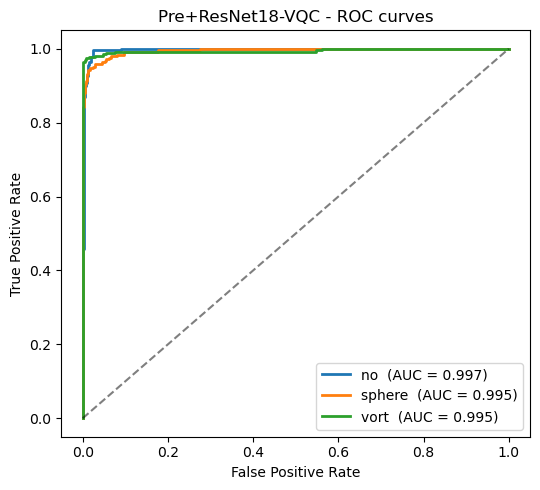

In [12]:
def plot_roc_curves(probs, y, class_names, title):
    n_cls = len(class_names)
    y_bin = label_binarize(y, classes=list(range(n_cls)))
    fig, ax = plt.subplots(figsize=(5.5, 5.0))
    for i, cname in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        ax.plot(fpr, tpr, lw=2, label=f"{cname}  (AUC = {auc(fpr, tpr):.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(title); ax.legend(loc="lower right")
    plt.tight_layout(); plt.show()


def evaluate_full(model, loader, class_names, tag):
    probs, preds, y = collect_predictions(model, loader, device)
    acc = accuracy_score(y, preds)
    y_bin = label_binarize(y, classes=list(range(len(class_names))))
    macro_auc = roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")
    p, r, f1, _ = precision_recall_fscore_support(y, preds, average=None, zero_division=0)
    p_m, r_m, f1_m, _ = precision_recall_fscore_support(y, preds, average="macro", zero_division=0)
    cm = confusion_matrix(y, preds)
    print(f"\n=== {tag} ===")
    print(f"Test accuracy: {acc:.4f}")
    print(f"Macro ROC-AUC: {macro_auc:.4f}")
    print(f"Macro P/R/F1: {p_m:.4f} / {r_m:.4f} / {f1_m:.4f}")
    print(classification_report(y, preds, target_names=class_names, digits=4))
    plot_confusion(cm, class_names, title=f"{tag} - confusion matrix")
    plot_roc_curves(probs, y, class_names, title=f"{tag} - ROC curves")
    return {
        "tag": tag, "accuracy": acc, "macro_auc": macro_auc,
        "macro_precision": p_m, "macro_recall": r_m, "macro_f1": f1_m,
        "per_class_precision": dict(zip(class_names, p.tolist())),
        "per_class_recall":    dict(zip(class_names, r.tolist())),
        "per_class_f1":        dict(zip(class_names, f1.tolist())),
        "probs": probs, "preds": preds, "targets": y,
    }


pre_vqc_results = evaluate_full(pre_vqc_model, test_loader, CLASS_NAMES, tag="Pre+ResNet18-VQC")

In [13]:
baseline_model, baseline_history = run_stage2(
    CFG, train_loader, val_loader,
    load_stage1=False,
    ckpt_save_path=CFG["baseline_ckpt"],
    run_tag="ImageNet-only-ResNet18-VQC",
    augmenter=augmenter,
)

[ImageNet-only-ResNet18-VQC] Skipping Stage-1 weights -> ImageNet-only.
[ImageNet-only-ResNet18-VQC] augmentation: ON


[ImageNet-only-ResNet18-VQC] ep 1/60:   0%|          | 0/118 [00:00<?, ?it/s]

[ImageNet-only-ResNet18-VQC] ep 01/60 | backbone=4.0e-05 bridge=2.0e-04 quantum=2.0e-03 | train loss=1.0867 acc=0.3354 | val loss=1.0728 acc=0.3339 *


[ImageNet-only-ResNet18-VQC] ep 2/60:   0%|          | 0/118 [00:00<?, ?it/s]

[ImageNet-only-ResNet18-VQC] ep 02/60 | backbone=6.0e-05 bridge=3.0e-04 quantum=3.0e-03 | train loss=1.0456 acc=0.3345 | val loss=1.0214 acc=0.3335 


...

[ImageNet-only-ResNet18-VQC] ep 58/60 | backbone=3.3e-07 bridge=1.6e-06 quantum=1.6e-05 | train loss=0.0479 acc=0.9854 | val loss=0.2000 acc=0.9496 


[ImageNet-only-ResNet18-VQC] ep 59/60:   0%|          | 0/118 [00:00<?, ?it/s]

[ImageNet-only-ResNet18-VQC] ep 59/60 | backbone=8.2e-08 bridge=4.1e-07 quantum=4.1e-06 | train loss=0.0464 acc=0.9865 | val loss=0.1917 acc=0.9513 


[ImageNet-only-ResNet18-VQC] ep 60/60:   0%|          | 0/118 [00:00<?, ?it/s]

[ImageNet-only-ResNet18-VQC] ep 60/60 | backbone=0.0e+00 bridge=0.0e+00 quantum=0.0e+00 | train loss=0.0461 acc=0.9862 | val loss=0.1872 acc=0.9545 

[ImageNet-only-ResNet18-VQC] Best val acc: 0.9567
[ImageNet-only-ResNet18-VQC] Saved best ckpt: ./checkpoints/baseline/resnet18.pth


In [14]:


class ClassicalModel(nn.Module):
    """
    Pure-classical baseline:
        frontend (ResNet + bridge MLP)  ->  Linear(n_qubits, n_classes)  ->  log_softmax

    Identical structure to Stage1Model EXCEPT the entire 'sigmoid*pi/2 -> VQC' block is dropped.
    The 8-d bridge output goes straight to the linear classifier.

    This isolates the contribution of the VQC: any accuracy gap between this model and
    Pre+<Backbone>-VQC is attributable to the quantum bottleneck.
    """
    def __init__(self, frontend: nn.Module, n_qubits: int, n_classes: int):
        super().__init__()
        self.frontend = frontend
        self.head = nn.Linear(n_qubits, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feats = self.frontend(x)
        return F.log_softmax(self.head(feats), dim=1)


def build_classical_model(cfg: Dict[str, Any]) -> ClassicalModel:
    fe = get_frontend(cfg["backbone"], cfg["n_qubits"], pretrained=cfg["pretrained"])
    return ClassicalModel(fe, n_qubits=cfg["n_qubits"], n_classes=cfg["n_classes"])



_m = build_classical_model(CFG).to(device)
_xb = torch.randn(2, 3, CFG["resize_to"], CFG["resize_to"], device=device)
_yb = _m(_xb)
print(f"ClassicalModel out shape: {tuple(_yb.shape)} (expected (2, {CFG['n_classes']}))")
print(f"ClassicalModel params: {sum(p.numel() for p in _m.parameters()):,}")
print(f"  backbone : {sum(p.numel() for p in _m.frontend.backbone.parameters()):,}")
print(f"  bridge   : {sum(p.numel() for p in _m.frontend.bridge.parameters()):,}")
print(f"  head     : {sum(p.numel() for p in _m.head.parameters()):,}")
print(f"  vqc      : 0  (this is the whole point)")
del _m, _xb, _yb

ClassicalModel out shape: (2, 3) (expected (2, 3))
ClassicalModel params: 11,352,323
  backbone : 11,176,512
  bridge   : 175,784
  head     : 27
  vqc      : 0  (this is the whole point)


In [15]:



CLASSICAL_DIR = os.path.join(CKPT_ROOT, "classical")
os.makedirs(CLASSICAL_DIR, exist_ok=True)
CFG["classical_ckpt"] = os.path.join(CLASSICAL_DIR, f"{_safe_name(CFG['backbone'])}.pth")


def get_classical_param_groups(model: ClassicalModel, cfg: Dict[str, Any]) -> List[Dict[str, Any]]:
    """
    Two param groups (no quantum group needed):
      backbone  -> stage1_lr_backbone  (preserve pretrained ImageNet features)
      bridge+head -> stage1_lr_bridge  (random init, full lr)
    """
    return [
        {"params": list(model.frontend.backbone.parameters()),
         "lr": cfg["stage1_lr_backbone"], "name": "backbone"},
        {"params": list(model.frontend.bridge.parameters()) + list(model.head.parameters()),
         "lr": cfg["stage1_lr_bridge"],   "name": "bridge+head"},
    ]


def run_classical(cfg, train_loader, val_loader, augmenter: Optional[nn.Module] = None):
    torch.manual_seed(cfg["seed"])
    model = build_classical_model(cfg).to(device)

    cw = cfg.get("class_weights")
    if cw is not None and any(w != 1.0 for w in cw):
        cw_t = torch.tensor(cw, dtype=torch.float32, device=device)
        criterion = nn.NLLLoss(weight=cw_t)
        print(f"[classical] using class weights {cw}")
    else:
        criterion = nn.NLLLoss()

    optimizer = optim.Adam(get_classical_param_groups(model, cfg), weight_decay=cfg["stage1_wd"])
    scheduler = LambdaLR(
        optimizer,
        lr_lambda=lambda e: warmup_cosine_factor(e, cfg["warmup_epochs"], cfg["stage1_epochs"]),
    )

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_state = -1.0, None
    print(f"[classical] pure classical: frontend + Linear({cfg['n_qubits']} -> {cfg['n_classes']})  (NO VQC)")
    print(f"[classical] augmentation: {'ON' if augmenter is not None else 'OFF'}")
    print(f"[classical] trainable params: "
          f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    for epoch in range(cfg["stage1_epochs"]):
        model.train()
        tr_loss = tr_correct = tr_total = 0
        pbar = tqdm(train_loader, desc=f"[classical] ep {epoch+1}/{cfg['stage1_epochs']}", leave=False)
        for xb, yb in pbar:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            if augmenter is not None and model.training:
                xb = augmenter(xb)
            optimizer.zero_grad(set_to_none=True)
            logp = model(xb)
            loss = criterion(logp, yb)
            loss.backward()
            if cfg.get("grad_clip"):
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            optimizer.step()
            tr_loss    += loss.item() * xb.size(0)
            tr_correct += (logp.argmax(1) == yb).sum().item()
            tr_total   += xb.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        train_loss, train_acc = tr_loss / tr_total, tr_correct / tr_total

        model.eval()
        v_loss = v_correct = v_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                logp = model(xb)
                v_loss    += criterion(logp, yb).item() * xb.size(0)
                v_correct += (logp.argmax(1) == yb).sum().item()
                v_total   += xb.size(0)
        val_loss, val_acc = v_loss / v_total, v_correct / v_total

        for k, v in zip(["train_loss", "train_acc", "val_loss", "val_acc"],
                        [train_loss, train_acc, val_loss, val_acc]):
            history[k].append(v)

        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, cfg["classical_ckpt"])

        scheduler.step()
        lrs = " ".join(f"{g['name']}={g['lr']:.1e}" for g in optimizer.param_groups)
        print(f"[classical] ep {epoch+1:02d}/{cfg['stage1_epochs']} | {lrs} | "
              f"train loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val loss={val_loss:.4f} acc={val_acc:.4f} {'*' if is_best else ''}")

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"\n[classical] Best val acc: {best_val_acc:.4f}")
    print(f"[classical] Saved best ckpt: {cfg['classical_ckpt']}")
    return model, history


t0 = time.time()
classical_model, classical_history = run_classical(
    CFG, train_loader, val_loader, augmenter=augmenter,
)
print(f"[classical] total time: {(time.time()-t0)/60:.1f} min")

[classical] using class weights [1.0, 2.5, 2.0]
[classical] pure classical: frontend + Linear(8 -> 3)  (NO VQC)
[classical] augmentation: ON
[classical] trainable params: 11,352,323


[classical] ep 1/40:   0%|          | 0/118 [00:00<?, ?it/s]

[classical] ep 01/40 | backbone=4.0e-05 bridge+head=4.0e-04 | train loss=1.1186 acc=0.3332 | val loss=1.0710 acc=0.3372 *


[classical] ep 2/40:   0%|          | 0/118 [00:00<?, ?it/s]

[classical] ep 02/40 | backbone=6.0e-05 bridge+head=6.0e-04 | train loss=1.0557 acc=0.3399 | val loss=1.0281 acc=0.3366 


...

[classical] ep 38/40 | backbone=8.0e-07 bridge+head=8.0e-06 | train loss=0.0739 acc=0.9768 | val loss=0.1598 acc=0.9524 


[classical] ep 39/40:   0%|          | 0/118 [00:00<?, ?it/s]

[classical] ep 39/40 | backbone=2.0e-07 bridge+head=2.0e-06 | train loss=0.0780 acc=0.9739 | val loss=0.1608 acc=0.9505 


[classical] ep 40/40:   0%|          | 0/118 [00:00<?, ?it/s]

[classical] ep 40/40 | backbone=0.0e+00 bridge+head=0.0e+00 | train loss=0.0747 acc=0.9762 | val loss=0.1668 acc=0.9536 

[classical] Best val acc: 0.9544
[classical] Saved best ckpt: ./checkpoints/classical/resnet18.pth
[classical] total time: 4.1 min


eval:   0%|          | 0/3 [00:00<?, ?it/s]


=== Classical-resnet18 (no VQC) ===
Test accuracy: 0.9440
Macro ROC-AUC: 0.9924
Macro P/R/F1: 0.9435 / 0.9447 / 0.9439
              precision    recall  f1-score   support

          no     0.9404    0.9651    0.9526       229
      sphere     0.9130    0.9277    0.9203       249
        vort     0.9771    0.9412    0.9588       272

    accuracy                         0.9440       750
   macro avg     0.9435    0.9447    0.9439       750
weighted avg     0.9446    0.9440    0.9441       750



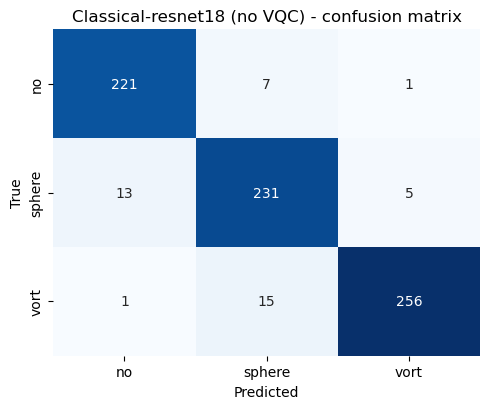

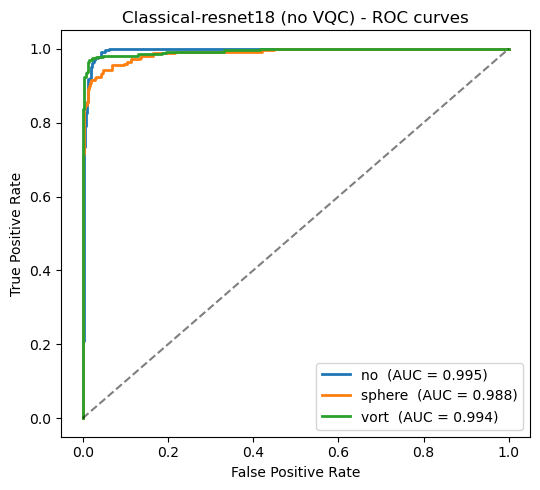

In [16]:


classical_results = evaluate_full(
    classical_model, test_loader, CLASS_NAMES,
    tag=f"Classical-{CFG['backbone']} (no VQC)",
)

=== Runs included ===
  + Pre+<Backbone>-VQC (Stage 1 -> Stage 2)
  + Pure classical <Backbone> (no VQC)
  + torchquantum_v10 (external reference)

=== Runs missing (skipped) ===
  - ImageNet-only-<Backbone>-VQC (no Stage 1)   (run CELL 12 to add)

=== Comparison ===
                                      model  test_accuracy  macro_AUC  macro_precision  macro_recall  macro_F1
                           Pre+ResNet18-VQC         0.9680     0.9956           0.9672        0.9682    0.9676
                Classical-resnet18 (no VQC)         0.9440     0.9924           0.9435        0.9447    0.9439
torchquantum_v10 (ResNet18+VQC, no Stage 1)         0.9240     0.9837           0.9241        0.9243    0.9240

=== Quantum-vs-classical analysis ===
Pure classical          | acc=0.9440  AUC=0.9924
Pre+<Backbone>-VQC      | acc=0.9680  AUC=0.9956  (Δacc=+0.0240, ΔAUC=+0.0032)

Verdict (Pre+VQC vs pure classical, on test acc): quantum BEATS classical by 2.40 %


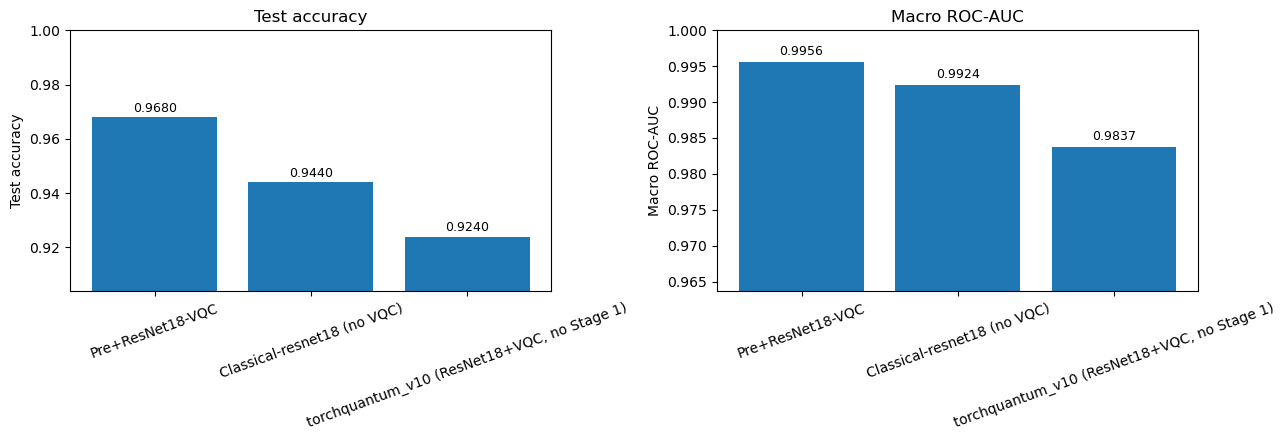

In [18]:


TORCHQUANTUM_V10_REF = {
    "tag":             "torchquantum_v10 (ResNet18+VQC, no Stage 1)",
    "accuracy":        0.9240,
    "macro_auc":       0.9837,
    "macro_precision": 0.9241,
    "macro_recall":    0.9243,
    "macro_f1":        0.9240,
}


def _row(d):
    return {"model":           d["tag"],
            "test_accuracy":   d.get("accuracy"),
            "macro_AUC":       d.get("macro_auc"),
            "macro_precision": d.get("macro_precision"),
            "macro_recall":    d.get("macro_recall"),
            "macro_F1":        d.get("macro_f1")}



rows = []
present = []
missing = []

for varname, label in [
    ("pre_vqc_results",   "Pre+<Backbone>-VQC (Stage 1 -> Stage 2)"),
    ("baseline_results",  "ImageNet-only-<Backbone>-VQC (no Stage 1)"),
    ("classical_results", "Pure classical <Backbone> (no VQC)"),
]:
    if varname in globals():
        rows.append(_row(globals()[varname]))
        present.append(label)
    else:
        missing.append((varname, label))


rows.append(_row(TORCHQUANTUM_V10_REF))
present.append("torchquantum_v10 (external reference)")

comparison_df = pd.DataFrame(rows)
for c in ["test_accuracy", "macro_AUC", "macro_precision", "macro_recall", "macro_F1"]:
    comparison_df[c] = pd.to_numeric(comparison_df[c], errors="coerce")

print("=== Runs included ===")
for p in present: print(f"  + {p}")
if missing:
    print("\n=== Runs missing (skipped) ===")
    for varname, label in missing:
        cell_hint = {"baseline_results": "CELL 12",
                     "classical_results": "CELL 15+16",
                     "pre_vqc_results":   "CELL 10+11"}[varname]
        print(f"  - {label}   (run {cell_hint} to add)")

print("\n=== Comparison ===")
print(comparison_df.to_string(index=False, na_rep="-", float_format="%.4f"))


if "pre_vqc_results" in globals() and "classical_results" in globals():
    classical_acc = classical_results["accuracy"]
    pre_vqc_acc   = pre_vqc_results["accuracy"]
    classical_auc = classical_results["macro_auc"]
    pre_vqc_auc   = pre_vqc_results["macro_auc"]

    print("\n=== Quantum-vs-classical analysis ===")
    print(f"Pure classical          | acc={classical_acc:.4f}  AUC={classical_auc:.4f}")
    if "baseline_results" in globals():
        b_acc = baseline_results["accuracy"]; b_auc = baseline_results["macro_auc"]
        print(f"ImageNet-only-VQC       | acc={b_acc:.4f}  AUC={b_auc:.4f}  "
              f"(Δacc={b_acc - classical_acc:+.4f}, ΔAUC={b_auc - classical_auc:+.4f})")
    print(f"Pre+<Backbone>-VQC      | acc={pre_vqc_acc:.4f}  AUC={pre_vqc_auc:.4f}  "
          f"(Δacc={pre_vqc_acc - classical_acc:+.4f}, ΔAUC={pre_vqc_auc - classical_auc:+.4f})")

    verdict = ("BEATS" if pre_vqc_acc > classical_acc
               else "LOSES TO" if pre_vqc_acc < classical_acc else "TIES")
    print(f"\nVerdict (Pre+VQC vs pure classical, on test acc): "
          f"quantum {verdict} classical by {abs(pre_vqc_acc - classical_acc)*100:.2f} %")


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
mask_acc = comparison_df["test_accuracy"].notna()
mask_auc = comparison_df["macro_AUC"].notna()

if mask_acc.any():
    sub = comparison_df.loc[mask_acc]
    axes[0].bar(sub["model"], sub["test_accuracy"])
    axes[0].set_ylabel("Test accuracy")
    axes[0].set_ylim(max(0.0, sub["test_accuracy"].min() - 0.02), 1.0)
    axes[0].set_title("Test accuracy")
    axes[0].tick_params(axis="x", rotation=20)
    for i, v in enumerate(sub["test_accuracy"]):
        axes[0].text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=9)

if mask_auc.any():
    sub = comparison_df.loc[mask_auc]
    axes[1].bar(sub["model"], sub["macro_AUC"])
    axes[1].set_ylabel("Macro ROC-AUC")
    axes[1].set_ylim(max(0.0, sub["macro_AUC"].min() - 0.02), 1.0)
    axes[1].set_title("Macro ROC-AUC")
    axes[1].tick_params(axis="x", rotation=20)
    for i, v in enumerate(sub["macro_AUC"]):
        axes[1].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=9)

plt.tight_layout(); plt.show()